In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from importlib.machinery import SourceFileLoader
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import os

preprocess = SourceFileLoader('preprocess', './utils/preprocess.py').load_module()
block_match = SourceFileLoader('block_match', './utils/block_match.py').load_module()

In [2]:
import glob
EDITIONS_DIR = "./processed_dataset"

edition_list = pd.read_csv(f"{EDITIONS_DIR}/edition_list.csv", header=None).squeeze().tolist()
edition_list = edition_list
dfs = []
for edition in tqdm(edition_list):
    df = pd.read_parquet(f"{EDITIONS_DIR}/df_to_match_edition_{edition}.parquet")
    dfs.append(df)

df_to_match = pd.concat(dfs, ignore_index=True)

100%|██████████| 27/27 [00:03<00:00,  7.75it/s]


In [35]:
class CommitteeModel:
    def __init__(self, models):
        self.committee_models = models

    def predict_proba(self, X):
        votes = [m.predict(X) for m in self.committee_models]
        votes_mean = np.array(votes).mean(axis=0)
        return np.column_stack([1 - votes_mean, votes_mean])

    def predict(self, X):
        return (self.predict_proba(X)[:,1] >= 0.5).astype(int)

    def member_probas(self, X):
        return np.column_stack([m.predict_proba(X)[:, 1] for m in self.committee_models])

models = []
for b in range(25):
    m = XGBClassifier(
        objective='binary:logistic',
        missing=-1,
    )
    m.load_model(f"./active_learning_results/ensemble/xgboost_iter7_{b}.json")
    models.append(m)

ensemble_model = CommitteeModel(models)
bst = ensemble_model

In [6]:
match_col_list = ["xing", "ming", "zihao", "diqu", "jigou_1", "jigou_2", "guanzhi_1", "ren_xian", "ren_sheng", "chushen_1"]
match_col_stroke_list = [f'{col}_stroke' for col in match_col_list]
match_col_pinyin_list = [f'{col}_pinyin' for col in match_col_list]
# model_feature_names = match_col_stroke_list + match_col_pinyin_list + ['pinji_diff', 'pinji_lower', 'ming_cnt_diff', 'ming_sim1', 'ming_sim2']
model_feature_names = match_col_stroke_list + match_col_pinyin_list + ['ming_cnt_diff', 'ming_sim1', 'ming_sim2', "same_year"]
guaranteed_match_col_list = ["xing", "ming", "ren_xian", "ren_sheng"]

## Matching: Load blocking data and get the matching probabilities between pairs

In [ ]:
import pickle

BLOCKING_RESULT_DIR = "./processed_data_for_blocking"

pattern = os.path.join(BLOCKING_RESULT_DIR, "chunk_*.pkl")
chunk_files = glob.glob(pattern)

edge_list = []

MATCH_THRESHOLD = 0.5

for chunk_file in tqdm(chunk_files):
    with open(chunk_file, "rb") as f:
        chunk_edition_log_list = pickle.load(f)
    for log_data in chunk_edition_log_list:
        validate_feature_list, validate_original_feature_list, validate_guaranteed_pairs_dict = log_data
        X_val = pd.DataFrame(validate_feature_list, columns = model_feature_names)
        validate_prob_list = bst.predict_proba(X_val)[:,1]
        validate_pred_list = validate_prob_list >= MATCH_THRESHOLD

        matched_pair_original_feature_list = [validate_original_feature_list[idx] for idx, pred in enumerate(validate_pred_list) if pred == 1]
        matched_pair_prob_list = [validate_prob_list[idx] for idx, pred in enumerate(validate_pred_list) if pred == 1]

        for idx, pair in enumerate(matched_pair_original_feature_list):
            left_idx = pair[0]
            right_idx = pair[1]
            if left_idx != right_idx:
                edge_list.append((left_idx, right_idx, matched_pair_prob_list[idx]))

100%|██████████| 5/5 [01:40<00:00, 20.06s/it]


In [37]:
# to directly get the edge list for guarantee matching
from char_converter import CharConverter
converter = CharConverter('v2t')

MAX_YEAR_DIFF = 20 # The max year diff allowed for guaranteed matching

guaranteed_match_col_processed_list = [f'{col}_processed' for col in guaranteed_match_col_list]

guaranteed_match_col_processed_df = pd.DataFrame(df_to_match[guaranteed_match_col_list].apply(lambda x: [converter.convert(i) for i in x], axis=1).tolist(), index=df_to_match.index)

df_to_match[guaranteed_match_col_processed_list] = guaranteed_match_col_processed_df
df_to_match[guaranteed_match_col_processed_list] = df_to_match[guaranteed_match_col_processed_list].replace('?', np.nan)

df_to_match_for_guarantee = df_to_match[["index", "year"] + guaranteed_match_col_processed_list]
df_to_match_for_guarantee.loc[:,'guarantee_key'] = df_to_match_for_guarantee[guaranteed_match_col_processed_list].astype(str).agg('_'.join, axis=1)

guaranteed_edge_list = []
idx_list_group_by_guarantee_key = df_to_match_for_guarantee.groupby('guarantee_key')['index'].apply(list).values
year_list_group_by_guarantee_key = df_to_match_for_guarantee.groupby('guarantee_key')['year'].apply(list).values

for idx_list, year_list in tqdm(zip(idx_list_group_by_guarantee_key, year_list_group_by_guarantee_key)):
    if len(idx_list) == 1:
        continue
    for idx, df_idx in enumerate(idx_list):
        for idx2, df_idx2 in enumerate(idx_list):
            if idx < idx2 and year_list[idx2] - year_list[idx] < MAX_YEAR_DIFF:
                guaranteed_edge_list.append((df_idx, df_idx2, 1))

/var/folders/b8/tdkq9sws3dv5r793sqypys080000gn/T/ipykernel_26677/3714232538.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_match_for_guarantee.loc[:,'guarantee_key'] = df_to_match_for_guarantee[guaranteed_match_col_processed_list].astype(str).agg('_'.join, axis=1)
42713it [00:00, 253351.32it/s]


In [38]:
len(edge_list), len(guaranteed_edge_list)

(443676, 1315204)

## Clustering

In [39]:
import networkx as nx

G = nx.Graph()

G.add_edges_from([(e[0], e[1], {'weight': e[2]}) for e in (edge_list+guaranteed_edge_list)])

In [40]:
partition = {}
for comm_idx, comm in enumerate(nx.connected_components(G)):
    for node in comm:
        partition[node] = comm_idx

In [41]:
df_list = []

for edition_idx in tqdm(range(len(edition_list))):
    curr_df = df_to_match[df_to_match["assigned_edition"] == edition_list[edition_idx]].reset_index(drop=True)
    curr_df['new_person_id'] = curr_df['index'].map(partition)
    df_list.append(curr_df)

100%|██████████| 27/27 [00:01<00:00, 16.91it/s]


In [42]:
new_df = pd.concat(df_list, axis=0)
auto_increment_id = int(max(new_df['new_person_id'].dropna(), default=0)) + 1
new_df.loc[new_df['new_person_id'].isna(), 'new_person_id'] = range(auto_increment_id, auto_increment_id + new_df['new_person_id'].isna().sum())

## Temporal-connectivity checking

In [ ]:
postprocess_iterative_partition = SourceFileLoader('iterative_partition', './utils/postprocess_iterative_partition.py').load_module()

MAX_STRANGE_COUNT = 5
MAX_STRANGE_RATIO = 0.3
MIN_SIZE_FOR_PARTITION = 20

# Get the final partition
final_partition = postprocess_iterative_partition.iterative_partitioning(
    new_df,
    G,
    min_size=MIN_SIZE_FOR_PARTITION,
    max_strange_count=MAX_STRANGE_COUNT,
    max_strange_ratio=MAX_STRANGE_RATIO,
    algorithm='leiden'
)

new_df['sub_comm'] = new_df['index'].map(final_partition)

100%|██████████| 29143/29143 [00:12<00:00, 2289.52it/s]


In [44]:
new_df['combined_sub_comm'] = new_df.apply(lambda x: f"{x['new_person_id']}_{x['sub_comm']}" if pd.notna(x['sub_comm']) else str(x['new_person_id']), axis=1)
new_df['new_person_id_2'] = pd.factorize(new_df['combined_sub_comm'])[0]

In [45]:
new_freq_list = new_df.groupby('new_person_id')['new_person_id'].count().values
new_id_list = new_df.groupby('new_person_id')['new_person_id'].count().index.tolist()

new_freq2_list = new_df.groupby('new_person_id_2')['new_person_id_2'].count().values
new_id2_list = new_df.groupby('new_person_id_2')['new_person_id_2'].count().index.tolist()

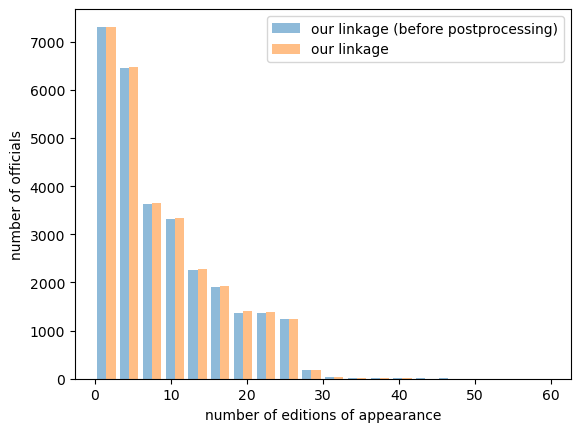

In [51]:
import matplotlib.pyplot as plt

plt.hist([new_freq_list, new_freq2_list], range=[0, 60], bins=20, label=['our linkage (before postprocessing)','our linkage'], alpha=0.5)
plt.xlabel('number of editions of appearance')
plt.ylabel('number of officials')
# plt.xlim(xmin=0, xmax = 60)
plt.legend()

In [52]:
print(np.mean(new_freq_list), np.std(new_freq_list), np.median(new_freq_list))
print(np.mean(new_freq2_list), np.std(new_freq2_list), np.median(new_freq2_list))

8.524105273993754 7.337082780178591 6.0
8.499606528210217 7.240707775774552 6.0
